In [1]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_anthropic import ChatAnthropic
from langsmith import Client
from dotenv import load_dotenv

load_dotenv()


embedding = UpstageEmbeddings(model="solar-embedding-1-large")

database = Chroma(
    embedding_function = embedding,
    collection_name = 'real_estate_tax',
    persist_directory = './real_estate_tax_collection'
)

retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 4,
        'fetch_k': 10,
        'lambda_mult': 0.6
    }
)

client = Client()

# 비용의 80%는 Haiku가, 정확도의 80%는 Sonnet/Opus가!!

smart_llm = ChatAnthropic(
    model='claude-opus-4-5-20251101',
    temperature= 0
)

llm = ChatAnthropic(
    model='claude-sonnet-4-5-20250929',
    temperature= 0
)

small_llm = ChatAnthropic(
    model='claude-haiku-4-5-20251001',
    temperature= 0
)

## ToolNode를 이용한 tool calling -> tool 사용

In [2]:
'''
LangChain을 통해 Tool 기능을 구현했을 떄의 workflow는 다음과 같다:

1. 사용자 query를 입력
2. query를 받은 LLM이 Tool calling 작성
3. Tool Calling을 받은 개발자가 tool에 입력 (결과) ---> 수동
4. 그 결과를 LLM이 설명
---

LangGraph의 tool node를 이용하면 자동으로 해당 tool로 이어줄 수 있게 된다.
'''

'\nLangChain을 통해 Tool 기능을 구현했을 떄의 workflow는 다음과 같다:\n\n1. 사용자 query를 입력\n2. query를 받은 LLM이 Tool calling 작성\n3. Tool Calling을 받은 개발자가 tool에 입력 (결과) ---> 수동\n4. 그 결과를 LLM이 설명\n---\n\nLangGraph의 tool node를 이용하면 자동으로 해당 tool로 이어줄 수 있게 된다.\n'

In [3]:
from langchain_core.tools import tool

@tool       # 데코레이터 @tool로 감싸고
def add(num1: int, num2: int) -> int:     # 함수와 변수의 이름, typehint가 schema(구조)로서, JSON 형식으로 LLM에 전달됨
    '''
    정수 num1와 num2를 더합니다. 
    '''         # 이 부분의 description(프롬프트와 같음)도 마찬가지로 LLM에 전달됨
    return num1+num2

@tool
def multiply(num1: int, num2: int) -> int:
    '''
    정수 num1와 num2를 곱합니다. 
    '''
    return num1*num2

In [ ]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply]

llm_with_tools = small_llm.bind_tools(tool_list)

tool_node = ToolNode(tool_list)

In [5]:
tool_call_of_llm = llm_with_tools.invoke('19 곱하기 19는?')
tool_call_of_llm

AIMessage(content=[{'text': '19를 19로 곱하겠습니다.', 'type': 'text'}, {'id': 'toolu_01QCnuatjKX6VdYcbFkBBspQ', 'input': {'num1': 19, 'num2': 19}, 'name': 'multiply', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_01LoR41ahQ7txB2quirKDRBF', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 723, 'output_tokens': 87, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019c26e7-dca0-7203-aaf7-00d12d3c6806-0', tool_calls=[{'name': 'multiply', 'args': {'num1': 19, 'num2': 19}, 'id': 'toolu_01QCnuatjKX6VdYcbFkBBspQ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 723, 'output_tokens': 87, 'total_tokens': 810, 'input_token_details': {'cache_read':

In [6]:
answer = tool_node.invoke({'messages': [tool_call_of_llm]})

In [7]:
answer

{'messages': [ToolMessage(content='361', name='multiply', tool_call_id='toolu_01QCnuatjKX6VdYcbFkBBspQ')]}

## Graph

In [40]:
from langgraph.graph import MessagesState, StateGraph

graph_builder = StateGraph(MessagesState)

In [41]:
def agent(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {'messages': [response]}

In [42]:
from langgraph.graph import START, END

def should_continue(state: MessagesState):
    messages = state['messages']
    if messages[-1].tool_calls:
        return 'tools'
    return END

## build

In [43]:
graph_builder.add_node('agent', agent) 
graph_builder.add_node('tools', tool_node)

In [44]:
graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent', 
    should_continue,
    {
        'tools': 'tools',
        END: END
    }
)
graph_builder.add_edge('tools', 'agent')


In [45]:
graph = graph_builder.compile()

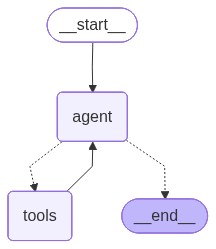

In [46]:
from IPython.display import display, Image

display(Image(graph.get_graph(xray=False).draw_mermaid_png()))

In [47]:
response = graph.invoke({'messages': ['19 곱하기 19는?']})

In [48]:
response

{'messages': [HumanMessage(content='19 곱하기 19는?', additional_kwargs={}, response_metadata={}, id='ad849228-3fd1-4f06-bd1d-9f5f437f98ef'),
  AIMessage(content=[{'text': '19를 19로 곱하겠습니다.', 'type': 'text'}, {'id': 'toolu_01JcGTELcwpQG1uyQgNVVYxV', 'input': {'num1': 19, 'num2': 19}, 'name': 'multiply', 'type': 'tool_use'}], additional_kwargs={}, response_metadata={'id': 'msg_012MxzFvGQT1j3gM3CHDKpEW', 'model': 'claude-haiku-4-5-20251001', 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'input_tokens': 723, 'output_tokens': 87, 'server_tool_use': None, 'service_tier': 'standard'}, 'model_name': 'claude-haiku-4-5-20251001', 'model_provider': 'anthropic'}, id='lc_run--019c2708-0786-7cb3-817d-ecbb67df0697-0', tool_calls=[{'name': 'multiply', 'args': {'num1': 19, 'num2': 19}, 'id': 'toolu_01JcGTELcwpQG1uyQgNVVYxV', 'type': 'tool_call'}],

In [49]:
response['messages'][-1].content

'19 곱하기 19는 **361**입니다.'

### 또는 이렇게 stream 할 수도

In [70]:
from langchain_core.messages import HumanMessage


for chunk in graph.stream({'messages': [HumanMessage("12312에 54342를 더하고 123을 곱하면??")]}, stream_mode= 'values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

12312에 54342를 더하고 123을 곱하면??
================================== Ai Message ==================================

[{'text': '이 문제를 단계별로 계산하겠습니다.\n\n먼저 12312에 54342를 더한 후, 그 결과에 123을 곱해야 합니다.', 'type': 'text'}, {'id': 'toolu_01VHkeMGnKt7ryzgkA1MgmSe', 'input': {'num1': 12312, 'num2': 54342}, 'name': 'add', 'type': 'tool_use'}]
Tool Calls:
  add (toolu_01VHkeMGnKt7ryzgkA1MgmSe)
 Call ID: toolu_01VHkeMGnKt7ryzgkA1MgmSe
  Args:
    num1: 12312
    num2: 54342
================================= Tool Message =================================
Name: add

66654
================================== Ai Message ==================================

[{'text': '이제 그 결과인 66654에 123을 곱하겠습니다.', 'type': 'text'}, {'id': 'toolu_01XyEFFhbrvYFJQ3wGCVjyhX', 'input': {'num1': 66654, 'num2': 123}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01XyEFFhbrvYFJQ3wGCVjyhX)
 Call ID: toolu_01XyEFFhbrvYFJQ3wGCVjyhX
  Ar